
<div dir=ltr align=center>

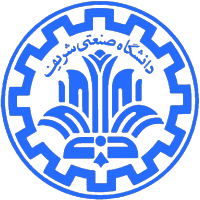

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Clustering: Gaussian Mixture Model <br>
<font color=696880 size=4>
    Prepared by Benyamin Ghanbari <br>

<font color=696880 size=2>
    Curated by Alireza Mirshafieian

____

# Student Information

In [1]:
student_number = '402102562'
full_name = 'Amitis Mirabedini'

# Customer Segmentation Using GMM 

## Description:
In this project, you will implement a Gaussian Mixture Model (GMM) from scratch and use it to perform customer segmentation based on demographic and behavioral data. Customer segmentation is the process of grouping customers into clusters such that customers within the same cluster are more similar to each other than to those in other clusters. In this assignment, segmentation is done using a probabilistic clustering approach, where each customer is assigned a probability of belonging to each cluster based on features such as Age, Annual Income, and Spending Score. 

**⚠️ Notice:** You are allowed to use only the imported libraries and must follow the provided function structure.

# 📝 **Project Instructions**

1. **Load the customer dataset**  
   Load the dataset containing customer information such as **Age, Annual Income, Spending Score**, and optionally **Gender**.

2. **Feature selection**  
    Anything that you need.

3. **Standardize features**  
   Normalize the numerical features using **standardization** so that each feature has **mean 0 and standard deviation 1**.

4. **Initialize GMM parameters**  
   Randomly initialize **cluster weights, means, and covariance matrices** for a chosen number of clusters **K**.

5. **Expectation-Maximization (EM) steps**  
   - **Expectation step:** Compute the **responsibility** of each cluster for every customer.  
   - **Maximization step:** Update **weights, means, and covariances** based on responsibilities.  
   - Repeat until **log-likelihood converges** or **max iterations** is reached.

6. **Multiple initializations**  
   Run the GMM algorithm **multiple times** with different random seeds and select the model with the **highest log-likelihood** to avoid poor local minima.

7. **Select the optimal number of clusters**  
   Compute **BIC (Bayesian Information Criterion)** for different values of **K** and choose the one with the **lowest BIC**.

8. **Assign clusters to customers**  
   For the final model, assign each customer to the cluster with the **highest responsibility**.

9. **Visualize clusters**  
   - **2D scatter plots:** Plot feature pairs (e.g., Age vs Income, Age vs Spending Score) with points colored by cluster.  
   - **Cluster centroids and circles:** Highlight **cluster centers** and **spread** using semi-transparent colored circles.  
   - **3D scatter plot:** Visualize clusters in 3D with **centroids marked**.



# 📤 **Expected Output**

- A **clustered customer dataset** showing each customer assigned to a **GMM cluster**  
- **2D scatter plots** of feature pairs (e.g., Age vs Income, Age vs Spending Score, Income vs Spending Score) with:  
  - Cluster points colored by cluster  
  - **Centroids** marked  
  - **Semi-transparent circles** showing cluster spread  
- A **3D scatter plot** visualizing all three features with cluster centroids highlighted  
- A **BIC vs. K plot** showing the Bayesian Information Criterion for different numbers of clusters, helping identify the **optimal K**  
- **Observe** which features distinguish clusters and how changing **K** affects segmentation quality


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Circle

In [3]:
# read data 

df = pd.read_csv('Mall_Customers.csv')
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [8]:
# data prepration (feature selection and scaling)

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

def standard_scale(X):
   means = np.mean(X, axis = 0)
   stds = np.std(X, axis = 0)
   X_scaled = (X - means) / stds

   return X_scaled, means, stds

X_scaled, means_X, stds_X = standard_scale(X)


In [18]:
# GMM from scratch

def gaussian_pdf_all(X, mean, cov):

    n_samples, n_features = X.shape

    cov_reg = cov + np.eye(n_features) * 1e-6

    det = np.linalg.det(cov_reg)

    inv = np.linalg.inv(cov_reg)

    norm_const = -0.5 * (n_features * np.log(2*np.pi) + np.log(det))

    diff = X - mean

    exponent = -0.5 * np.sum((diff @ inv) * diff, axis=1)

    return np.exp(norm_const + exponent)


def initialize_parameters(X, k, rng):
    n_samples, n_features = X.shape

    weights = np.ones(k) / k
    indices = rng.choice(n_samples, k, replace=False)
    means = X[indices]

    covs = np.array([np.eye(n_features) for _ in range(k)])

    return weights, means, covs


def expectation_step(X, weights, means, covs):

    n_samples = X.shape[0]
    k = len(weights)

    likelihoods = np.zeros((n_samples, k))

    for i in range(k):
        likelihoods[:, i] = weights[i] * gaussian_pdf_all(X, means[i], covs[i])

    total_likelihoods = np.sum(likelihoods, axis=1, keepdims=True)

    resp = likelihoods / total_likelihoods

    return resp


def maximization_step(X, resp):

    n_samples, n_features = X.shape
    k = resp.shape[1]

    N_k = np.sum(resp, axis=0)

    weights = N_k / n_samples

    means = (resp.T @ X) / N_k[:, np.newaxis]

    covs = np.zeros((k, n_features, n_features))
    for i in range(k):
        diff = X - means[i]
        covs[i] = (diff.T @ (diff * resp[:, i][:, np.newaxis])) / N_k[i]

    return weights, means, covs

def compute_log_likelihood(X, weights, means, covs):
    n_samples = X.shape[0]
    k = len(weights)

    likelihoods = np.zeros((n_samples, k))
    for i in range(k):
        likelihoods[:, i] = weights[i] * gaussian_pdf_all(X, means[i], covs[i])

    ll = np.sum(np.log(np.sum(likelihoods, axis=1)))

    return ll


def gmm_train(X, k, max_iter=200, tol=1e-4, seed=None):
    rng = np.random.RandomState(seed)

    weights, means, covs = initialize_parameters(X, k, rng)

    prev_ll = -np.inf
    resp = None

    for iteration in range(max_iter):
        resp = expectation_step(X, weights, means, covs)

        weights, means, covs = maximization_step(X, resp)

        ll = compute_log_likelihood(X, weights, means, covs)
        if np.abs(ll - prev_ll) < tol:
            break
        prev_ll = ll

    return weights, means, covs, resp, ll

In [19]:
# compute best k using BIC

def compute_bic(ll, k, n, d):
    
    num_params = k * d + k * d * (d + 1) / 2 + (k - 1)
    return -2 * ll + num_params * np.log(n)



bic_values = []
k_range = range(2,9)
best_models = []

n_samples, n_features = X_scaled.shape
best_bic = np.inf
best_k = None
best_model_params = None

for k in k_range:
    best_ll_run = -np.inf
    best_params_run = None

    for run in range(5):
        weights, means, covs, resp, ll = gmm_train(X_scaled, k, seed=run*10 + k)
        if ll > best_ll_run:
            best_ll_run = ll
            best_params_run = (weights, means, covs, resp, ll)

    current_bic = compute_bic(best_ll_run, k, n_samples, n_features)
    bic_values.append(current_bic)
    best_models.append(best_params_run)

    if current_bic < best_bic:
        best_bic = current_bic
        best_k = k
        best_model_params = best_params_run

print("\nBest k =", best_k)


Best k = 4


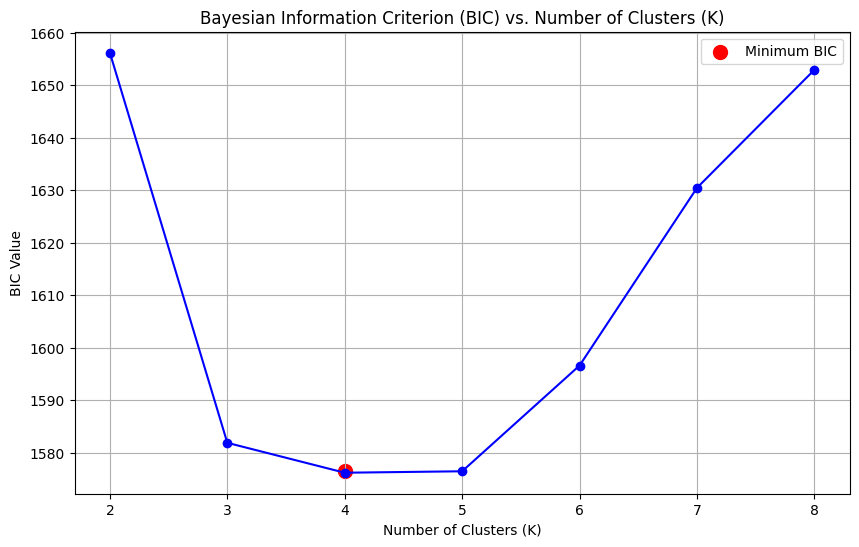

In [20]:
# BIC plot 
plt.figure(figsize=(10, 6))
plt.plot(k_range, bic_values, marker='o', linestyle='-', color='b')
plt.title('Bayesian Information Criterion (BIC) vs. Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('BIC Value')
plt.xticks(k_range)


plt.scatter(best_k, bic_values[best_k_index], color='red', s=100, label='Minimum BIC')

plt.legend()
plt.grid(True)
plt.savefig('bic_vs_k_plot.png')


In [22]:

optimal_weights, optimal_means, optimal_covs, optimal_resp, optimal_ll = best_model_params

cluster_assignments = np.argmax(optimal_resp, axis=1)

df['GMM_Cluster'] = cluster_assignments

optimal_means_original_scale = optimal_means * stds_X + means_X

print(f"\nOptimal Cluster Means (Original Scale, K={best_k}):")
print(pd.DataFrame(optimal_means_original_scale, columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']))
print("\n--- Clustered Customer Data Prepared for Visualization ---")


Optimal Cluster Means (Original Scale, K=4):
         Age  Annual Income (k$)  Spending Score (1-100)
0  32.694341           86.318586               81.968954
1  52.951368           54.791290               49.377373
2  43.831219           62.971366               20.145545
3  24.350739           44.443851               59.456198

--- Clustered Customer Data Prepared for Visualization ---


C:\Users\Notebook\AppData\Local\Temp\ipykernel_18304\3574735044.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  segment_cmap = plt.cm.get_cmap('viridis', best_k)


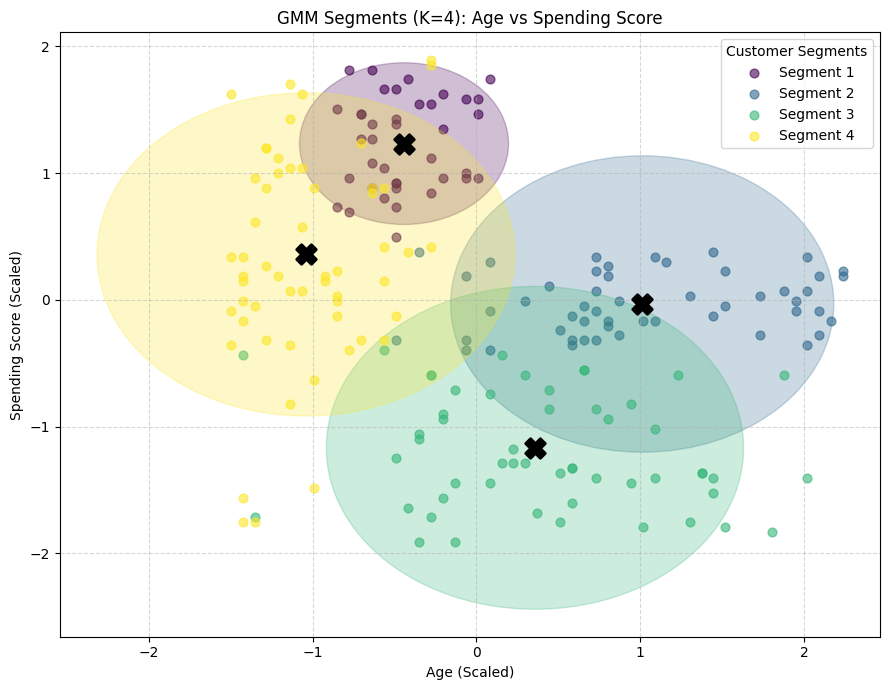

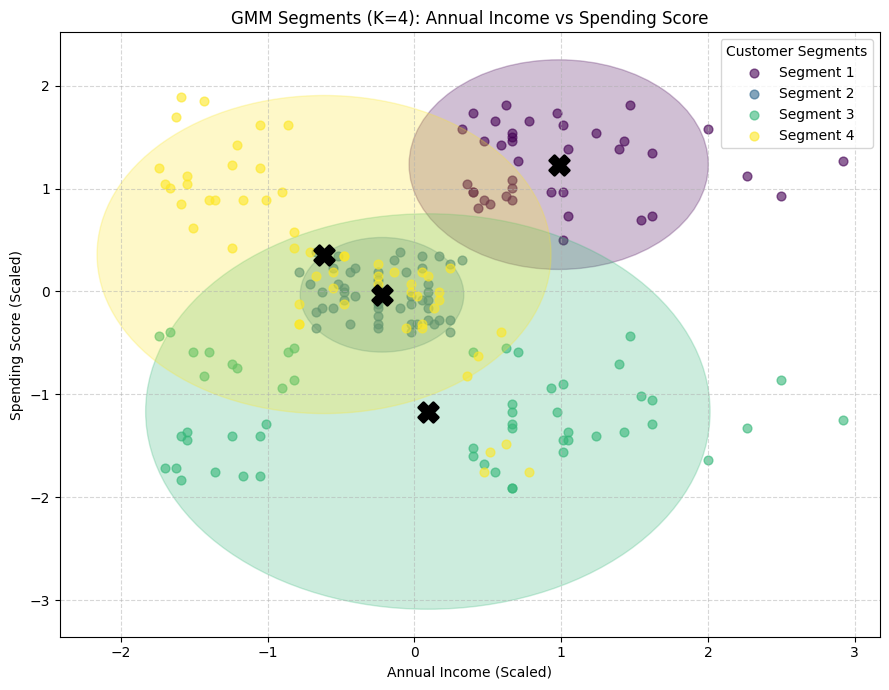

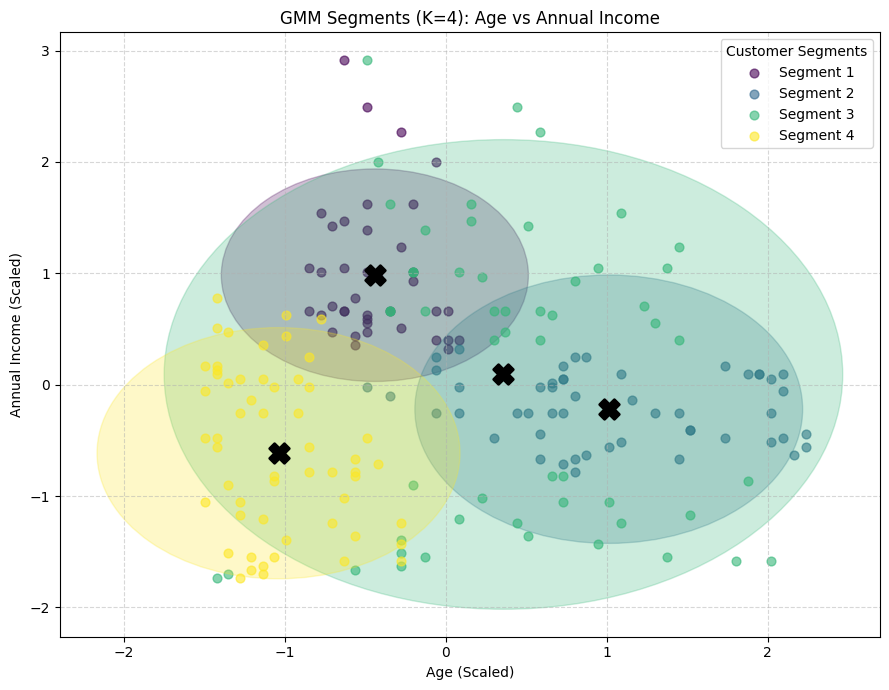

In [29]:

optimal_means = final_means
optimal_covs = final_covs
optimal_ll = final_ll



plot_feature_names = ['Age (Scaled)', 'Annual Income (Scaled)', 'Spending Score (Scaled)']

segment_cmap = plt.cm.get_cmap('viridis', best_k) 



def plot_gmm_clusters_2d(f1_index, f2_index, title):
    
    plt.figure(figsize=(9, 7))
    ax = plt.gca()

    for segment_index in range(best_k):
        segment_points = X_scaled[cluster_assignments == segment_index]
        current_color = segment_cmap(segment_index)
        
        ax.scatter(
            segment_points[:, f1_index],
            segment_points[:, f2_index],
            s=40,
            alpha=0.6,
            color=current_color,
            label=f'Segment {segment_index + 1}' # Better label: Segment 1, 2, 3...
        )

        centroid_x, centroid_y = optimal_means[segment_index, f1_index], optimal_means[segment_index, f2_index]
        ax.scatter(centroid_x, centroid_y, marker='X', s=200, color='k', linewidth=2, zorder=10)

        
        cov_2d = optimal_covs[segment_index][np.ix_([f1_index, f2_index], [f1_index, f2_index])]
        
        radius = 2 * np.sqrt(np.mean(np.diag(cov_2d))) 
        
        circle = Circle((centroid_x, centroid_y), radius, color=current_color, alpha=0.25)
        ax.add_patch(circle)

    ax.set_xlabel(plot_feature_names[f1_index])
    ax.set_ylabel(plot_feature_names[f2_index])
    ax.set_title(title)
    ax.legend(title='Customer Segments')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()



plot_gmm_clusters_2d(
    0, 2,
    title=f'GMM Segments (K={best_k}): Age vs Spending Score'
)

plot_gmm_clusters_2d(
    1, 2,
    title=f'GMM Segments (K={best_k}): Annual Income vs Spending Score'
)

plot_gmm_clusters_2d(
    0, 1,
    title=f'GMM Segments (K={best_k}): Age vs Annual Income'
)

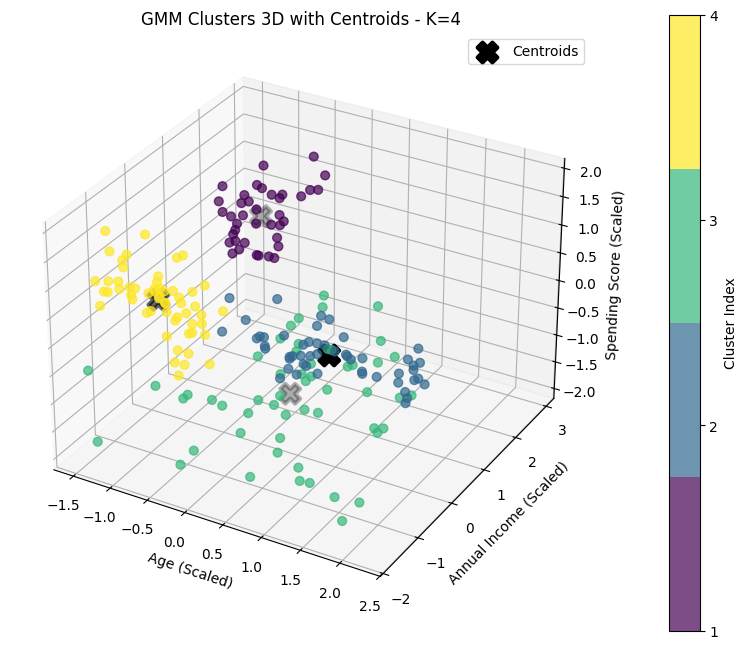

In [ ]:



fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
    c=cluster_assignments, 
    cmap=segment_cmap, 
    s=40, 
    alpha=0.7
)

ax.scatter(
    final_means[:, 0], final_means[:, 1], final_means[:, 2],
    c='k', 
    s=200, 
    marker='X', 
    linewidth=3, 
    label='Centroids'
)

ax.set_xlabel(plot_feature_names[0])
ax.set_ylabel(plot_feature_names[1])
ax.set_zlabel(plot_feature_names[2])
ax.set_title(f'GMM Clusters 3D with Centroids - K={best_k}')

cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('Cluster Index')
cbar.set_ticks(np.arange(best_k))
cbar.set_ticklabels(np.arange(1, best_k + 1)) 
ax.view_init(elev=30, azim=-60)

ax.legend()
plt.show()

In [42]:
df['Cluster'] = cluster_assignments
df.to_csv('segmented_customers.csv')
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),GMM_Cluster,Cluster
0,1,Male,19,15,39,2,2
1,2,Male,21,15,81,3,3
2,3,Female,20,16,6,2,2
3,4,Female,23,16,77,3,3
4,5,Female,31,17,40,2,2
5,6,Female,22,17,76,3,3
6,7,Female,35,18,6,2,2
7,8,Female,23,18,94,3,3
8,9,Male,64,19,3,2,2
9,10,Female,30,19,72,3,3


In [11]:
# Your first 10 row shoud be like : 



,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,1,Male,19,15,39,3
1,1,2,Male,21,15,81,0
2,2,3,Female,20,16,6,3
3,3,4,Female,23,16,77,0
4,4,5,Female,31,17,40,3
5,5,6,Female,22,17,76,0
6,6,7,Female,35,18,6,3
7,7,8,Female,23,18,94,0
8,8,9,Male,64,19,3,3
9,9,10,Female,30,19,72,0
